# Working Example to Highlight New CSM usage

This example is very basic, and will be used to demonstrate inputs and outputs as the model is developed.

In [1]:
from copy import deepcopy

import pandas as pd
from attrs import fields

from csm.models.base_model import CSMBase
from csm.models.nlr2015 import Land2015NLR
from csm import plot

pd.options.display.float_format = "{:,.2f}".format

The `CSMBase` is where all the base data validation and inputs will be provided. This
class will also store key information to be able to automatically generate
WISDEM-compliant models (a possibly working implementation exists at `csm/wisdem_api.py`).

In [2]:
# an input
blade_mass_coeff = fields(CSMBase).blade_mass_coeff
print(f"Blade mass coefficient default value: {blade_mass_coeff.default}")
print(f"Blade mass coefficient metadata: {blade_mass_coeff.metadata}")
print()

# an output that can also be provided as input
blade_mass = fields(CSMBase).blade_mass
print(f"Blade mass default value: {blade_mass.default}")
print(f"Blade mass metadata: {blade_mass.metadata}")

Blade mass coefficient default value: None
Blade mass coefficient metadata: {'units': 'unitless', 'io': 'input'}

Blade mass default value: None
Blade mass metadata: {'units': 'kg', 'io': 'both'}


## Creating a model from the base model

This is a simple demonstration of how to create a model. Please note this is in progress, in
particular, there is not yet an implementation of the 2015 model, so the defaults that will get
applied to the base model in a subclass are kept separate from the sample inputs for tracking
purposes.

In [3]:
# default values from past implementations
defaults_2015_land = {
    "blade_mass_coeff": 0.5,
    "blade_mass_cost_coeff": 14.6,
    "hub_mass_coeff": 2.3,
    "hub_mass_intercept": 1320.0,
    "hub_mass_cost_coeff": 3.9,
    "pitch_bearing_mass_coeff": 0.1295,
    "pitch_bearing_mass_intercept": 491.31,
    "bearing_housing_fraction": 0.3280,
    "mass_sys_offset": 555.0,
    "pitch_system_mass_cost_coeff": 22.1,
    "spinner_mass_coeff": 15.5,
    "spinner_mass_intercept": -980.0,
    "spinner_mass_cost_coeff": 11.1,
    "lss_mass_coeff": 13.0,
    "lss_mass_exp": 0.65,
    "lss_mass_intercept": 775,
    "lss_mass_cost_coeff": 11.9,
    "bearing_mass_coeff": 0.0001,
    "bearing_mass_exp": 3.5,
    "bearing_mass_cost_coeff": 4.5,
    "gearbox_torque_density": 200,
    "gearbox_torque_cost": 50,
    "brake_mass_coeff": 0.00122,
    "brake_mass_cost_coeff": 3.6254,
    "hss_mass_coeff": 0.19894,
    "hss_mass_cost_coeff": 6.8,
    "generator_mass_coeff": 2.3,
    "generator_mass_intercept": 3400,
    "generator_mass_cost_coeff": 12.4,
    "bedplate_mass_exp": 2.2,
    "bedplate_mass_cost_coeff": 2.9,
    "yaw_system_non_bearing_mass_coeff": 1.5,
    "yaw_system_mass_coeff": 0.0009,
    "yaw_system_mass_exp": 3.314,
    "yaw_system_mass_cost_coeff": 8.3,
    "hvac_mass_coeff": 0.08,
    "hvac_mass_cost_coeff": 124,
    "nacelle_cover_mass_coeff": 1.2817,
    "nacelle_cover_mass_intercept": 428.19,
    "nacelle_cover_mass_cost_coeff": 5.7,
    "crane_mass": 3000,
    "crane_cost": 12000.0,
    "platform_mainframe_mass_coeff": 0.125,
    "platform_mainframe_mass_cost_coeff": 17.1,
    "transformer_mass_coeff": 1.9150,
    "transformer_mass_intercept": 1910.0,
    "transformer_mass_cost_coeff": 18.8,
    "tower_mass_coeff": 19.828,
    "tower_mass_exp": 2.0282,
    "tower_mass_cost_coeff": 2.9,
    "converter_mass_cost_coeff": 18.8,
    "controls_cost_coeff": 21.15,
    "electrical_connection_cost_coeff": 41.85,
    "tower_mass_coeff": 19.828,
    "tower_mass_exp": 2.0282,
    "tower_mass_cost_coeff": 2.9,
}

# example input
csm_2015_inputs = {
    "turbine_class": 1,
    "efficiency_max": 0.9,
    "num_blades": 3,
    "num_bearings": 2,
    "rated_power_kw": 5000,
    "blade_has_carbon": False,
    "has_crane": True,
    "rotor_diameter": 126,
    "max_tip_speed": 80,
    "tower_length": 90,
}

rep15 = CSMBase.from_dict(defaults_2015_land | csm_2015_inputs)

In [4]:
rep15.run()

### Quick demonstration of run time

In [5]:
%%timeit
rep15 = CSMBase.from_dict(defaults_2015_land | csm_2015_inputs)

236 μs ± 4.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [6]:
%%timeit
rep15 = CSMBase.from_dict(defaults_2015_land | csm_2015_inputs)
rep15.run()

387 μs ± 9.85 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Results Breakdowns

The `Land2015NLR` and `CSMBase` using the above inputs all match the WISDEM implementation of the 2015 model

In [7]:
mass = pd.DataFrame.from_dict(rep15.get_mass_results(), orient="index").rename(
    columns={0: "Mass (kg)"}
)
cost = pd.DataFrame.from_dict(rep15.get_cost_results(), orient="index").rename(
    columns={0: "Cost (USD)"}
)
mass.index = mass.index.str.replace("_mass", "")
cost.index = cost.index.str.replace("_cost", "")
results = mass.join(cost, how="outer")
results.index.name = "Component"
results

,Mass (kg),Cost (USD)
Component,,
bearing,"2,245.42","10,104.37"
bedplate,"41,765.26","121,119.26"
blade,"18,590.67","271,423.76"
brake,"5,337.50","19,350.57"
controls,0.00,"105,750.00"
converter,0.00,0.00
electrical_connection,0.00,"209,250.00"
gearbox,"21,875.00","218,750.00"
generator,"14,900.00","184,760.00"


## Parameterization

In [8]:
# 2015 defaults
base_inputs = defaults_2015_land | csm_2015_inputs
del base_inputs["max_tip_speed"]

del base_inputs["tower_length"]

# example input
parameters = {
    "max_tip_speed": ("range", 80, 90, 3),
    "tower_length": ("range", 80, 100, 3),
}

# NOTE: a subset of results can be provided, but this will produce all outputs by default
param_results = CSMBase.parameterize(base_inputs, parameters)
param_results

max_tip_speed                     80.00                            \
tower_length                     80.00        90.00        100.00   
bearing_cost                  10,104.37    10,104.37    10,104.37   
bearing_mass                   2,245.42     2,245.42     2,245.42   
bedplate_cost                121,119.26   121,119.26   121,119.26   
bedplate_mass                 41,765.26    41,765.26    41,765.26   
blade_cost                   271,423.76   271,423.76   271,423.76   
blade_mass                    18,590.67    18,590.67    18,590.67   
brake_cost                    19,350.57    19,350.57    19,350.57   
brake_mass                     5,337.50     5,337.50     5,337.50   
controls_cost                105,750.00   105,750.00   105,750.00   
controls_mass                      0.00         0.00         0.00   
converter_cost                     0.00         0.00         0.00   
converter_mass                     0.00         0.00         0.00   
electrical_connection_cost   209,250.00   209,250.00   209,250.00   
electrical_connection_mass         0.00         0.00         0.00   
gearbox_cost                 218,750.00   218,750.00   218,750.00   
gearbox_mass                  21,875.00    21,875.00    21,875.00   
generator_cost               184,760.00   184,760.00   184,760.00   
generator_mass                14,900.00    14,900.00    14,900.00   
high_speed_shaft_cost          6,763.96     6,763.96     6,763.96   
high_speed_shaft_mass            994.70       994.70       994.70   
hub_cost                     171,906.29   171,906.29   171,906.29   
hub_mass                      44,078.54    44,078.54    44,078.54   
hub_system_cost              421,362.42   421,362.42   421,362.42   
hub_system_mass               55,850.44    55,850.44    55,850.44   
hydraulic_cooling_cost        49,600.00    49,600.00    49,600.00   
hydraulic_cooling_mass           400.00       400.00       400.00   
low_speed_shaft_cost         271,561.32   271,561.32   271,561.32   
low_speed_shaft_mass          22,820.28    22,820.28    22,820.28   
nacelle_cost               1,665,612.93 1,665,612.93 1,665,612.93   
nacelle_cover_cost            38,969.13    38,969.13    38,969.13   
nacelle_cover_mass             6,836.69     6,836.69     6,836.69   
nacelle_mass                 151,455.88   151,455.88   151,455.88   
pitch_system_cost            238,655.82   238,655.82   238,655.82   
pitch_system_mass             10,798.91    10,798.91    10,798.91   
platform_mainframe_cost      101,273.25   101,273.25   101,273.25   
platform_mainframe_mass        8,220.66     8,220.66     8,220.66   
rated_rpm                         12.13        12.13        12.13   
rotor_cost                 1,235,633.68 1,235,633.68 1,235,633.68   
rotor_mass                   111,622.45   111,622.45   111,622.45   
rotor_torque                   4,375.00     4,375.00     4,375.00   
spinner_cost                  10,800.30    10,800.30    10,800.30   
spinner_mass                     973.00       973.00       973.00   
tower_cost                   416,412.75   528,775.79   654,752.11   
tower_mass                   143,590.60   182,336.48   225,776.59   
transformer_cost             215,918.00   215,918.00   215,918.00   
transformer_mass              11,485.00    11,485.00    11,485.00   
turbine_cost               3,317,659.36 3,430,022.40 3,555,998.72   
turbine_cost_kw                  663.53       686.00       711.20   
turbine_mass                 406,668.93   445,414.81   488,854.92   
yaw_system_cost              102,338.69   102,338.69   102,338.69   
yaw_system_mass               12,329.96    12,329.96    12,329.96   

max_tip_speed                     85.00                            \
tower_length                     80.00        90.00        100.00   
bearing_cost                  10,104.37    10,104.37    10,104.37   
bearing_mass                   2,245.42     2,245.42     2,245.42   
bedplate_cost                121,119.26   121,119.26   121,119.26 

## IRS Tables

**Notes**
1. Only blade and hub calculations have been fully implemented, so everything else is
   placeholder values (e.g., nacelle cost) or nonexistent (e.g., tower cost).
2. The inputs to `irs_mpc_breakdown` incorporate inputs that are not included in CSM
   equations, but could be added as model inputs if desired.

In [9]:
rep15.irs_mpc_breakdown(
    turbine_production_cost=1500,
    tower_flange_material_cost=2000,
    tower_flange_production_cost=1000,
)

cost  Value
APC                                  MPC                                
Wind Turbine                         Blade             271,423.76  12.84
                                     Hub               171,906.29   8.13
                                     Nacelle         1,665,612.93  78.81
                                     Power Converter            -      -
                                     Production          1,500.00   0.07
Wind Tower Flange                    Material            2,000.00   0.09
                                     Production          1,000.00   0.05
Tower                                -                          -      -
Steel or iron products in foundation -                          -      -
Total                                -               2,113,442.98 100.00

In [10]:
rep15.total_domestic_content(
    turbine_production_cost=1500,
    tower_flange_material_cost=2000,
    tower_flange_production_cost=1000,
    domestic=["tower_flange_material", "tower_flange_production", "nacelle"],
    return_table=True,
)

category  \
APC                                  MPC                                        
Wind Turbine                         Blade                              blade   
                                     Hub                                  hub   
                                     Nacelle                          nacelle   
                                     Power Converter          power_converter   
                                     Production            turbine_production   
Wind Tower Flange                    Material           tower_flange_material   
                                     Production       tower_flange_production   
Tower                                -                                      -   
Steel or iron products in foundation -                                      -   
Total                                -                                      -   

                                                             cost  Value  \
APC                                  MPC                                   
Wind Turbine                         Blade             271,423.76  12.84   
                                     Hub               171,906.29   8.13   
                                     Nacelle         1,665,612.93  78.81   
                                     Power Converter         0.00   0.00   
                                     Production          1,500.00   0.07   
Wind Tower Flange                    Material            2,000.00   0.09   
                                     Production          1,000.00   0.05   
Tower                                -                       0.00   0.00   
Steel or iron products in foundation -                       0.00   0.00   
Total                                -               2,113,442.98 100.00   

                                                     Domestic  
APC                                  MPC                       
Wind Turbine                         Blade               0.00  
                                     Hub                 0.00  
                                     Nacelle             0.00  
                                     Power Converter     0.00  
                                     Production          0.00  
Wind Tower Flange                    Material            0.09  
                                     Production          0.05  
Tower                                -                   0.00  
Steel or iron products in foundation -                   0.00  
Total                                -                   0.14

## 2015 WISDEM/Paul Crook Replication

Below is highlighting that the various iterations of the 2015 model are available as `Land2015NLR`
with all the expected defaults readily available.

In [11]:
nlr2015 = Land2015NLR.from_dict(csm_2015_inputs)
nlr2015.run()

mass = pd.DataFrame.from_dict(nlr2015.get_mass_results(), orient="index").rename(
    columns={0: "Mass (kg)"}
)
cost = pd.DataFrame.from_dict(nlr2015.get_cost_results(), orient="index").rename(
    columns={0: "Cost (USD)"}
)
mass.index = mass.index.str.replace("_mass", "")
cost.index = cost.index.str.replace("_cost", "")
results = mass.join(cost, how="outer")
results.index.name = "Component"
results

,Mass (kg),Cost (USD)
Component,,
bearing,"2,245.42","10,104.37"
bedplate,"41,765.26","121,119.26"
blade,"18,590.67","271,423.76"
brake,"5,337.50","19,350.57"
controls,0.00,"105,750.00"
converter,0.00,0.00
electrical_connection,0.00,"209,250.00"
gearbox,"21,875.00","218,750.00"
generator,"14,900.00","184,760.00"


## Building a Custom Model

In this example, we will create a new model that modifies the blade mass calculation, and its
dependent variables. This will mirror the `Land2020NLR` model (work in progress), which is based
on the `Empirical2020` model.

### Imports and setup

Aside from the base model, we also need to be able to access the actual attribute data
provided by the `attrs` dataclass. This will be useful for simple reuse of existing
variables

```python
from attrs import define, fields

from csm.models.base_model import CSMBase
from csm.models.utils import create_field

base = fields(CSMBase)
```

### Class creation

Be sure to wrap the class with the `attrs.define` decorator, and subclass the base model or
another existing implementation closely matching the desired relationships.

```python
@define
class CustomModel(CSMBase):
```

#### Updating the inputs and attributes

For easy reuse of the base model's attributes, we `reuse` the focal attribute's existing
type data, metadata, and conversion and validation routines. However, we also want
to ensure users don't change the `blade_has_carbon` attribute, so we set `init=False` to
cause the model to error out on initialization if the user provides a value for it.

In this example, we must also create a new attribute `blade_mass_exp`. It's important to note that
`units="unitless"` and `io_type="input"` are the defaults and the metadata used for making the model
available to WISDEM with `io_type` also helping with data validation. If your custom model is not
intended to be integrated into the codebase, or be used in a WISDEM workflow, `units` may be ignored.
However, when using, be sure to check the documentation for `csm.models.utils.create_field` on their
proper usage. In general, units should align with
[OpenMDAO units](https://openmdao.org/newdocs/versions/latest/features/units.htm) and
`io_type` should be one of "input" (strictly an input), "output" (strictly a calculated value), or
"both" (a calculated value that could be hard-coded as an input, i.e., custom blade mass calculated
outside of CSM).

```python
    turbine_class = base.turbine_class.reuse(default=1)
    blade_has_carbon = base.blade_has_carbon.reuse(default=True, init=False)
    blade_mass_exp = create_field(obj=float, units="unitless", io_type="input", default=9.2157)
```

#### Updating the parameter mapping and post initialization hook

This step is critical as it defines what each attribute's dependent attributes are, enabling the
streamlined data checking and validation. Without this mapping, updating an attribute's value will
incorrectly clear an upstream calculated value. Below we are updating the `blade_mass` to 
no longer need the `blade_has_carbon` or `turbine_class` attributes, and add `blade_mass_exp`.
Once the `parameter_map` is updated, the base class' method can be run `super.__attrs_post_init__()`.

```python
    def __attrs_post_init__(self):
        # NOTE: we are changing the blade mass calculation's requirements, and need to
        # update the parameter relationships
        self.parameter_map["blade_mass"] = (
            "rotor_diameter", "blade_mass_coeff", "blade_mass_exp"
        )
        super().__attrs_post_init__()
```

#### Defining the new scaling relationship

Please note, the docstring has not been created in this example, but please follow the examples
set forth in `CSMBase` or any custom models for the information that should be provided.

The first three lines are used to determine if the focal variable has already been calculated or
provided. If it has, then the calculation should return early, otherwise the calculation should
proceed. These method should not return a value, instead act as setters for the calculated
value. It is important to adhere to the existing attribute naming conventions to avoid errors at
runtime.

```python
    def calculate_blade_mass(self):
        exists = self._prepare_calculation("blade_mass")
        if exists:
            return

        self.blade_mass = self.blade_mass_coeff * (self.rotor_diameter / 2) ** self.blade_mass_exp
```

### The full implementation

In [12]:
from attrs import define, fields

from csm.models.base_model import CSMBase
from csm import Land2015NLR
from csm.models.utils import create_field

# NOTE: This is slightly different (NLR2015, not CSMBase) because we are demonstrating
# a minimal example that we want to demonstrate results with.
base = fields(CSMBase)


@define
class CustomModel(CSMBase):
    turbine_class = base.turbine_class.reuse(default=1)
    blade_has_carbon = base.blade_has_carbon.reuse(default=True, init=False)
    blade_mass_coeff = base.blade_mass_coeff.reuse(default=9.2157)
    blade_mass_exp = create_field(obj=float, units="unitless", io_type="input", default=1.7679)

    def __attrs_post_init__(self):
        # NOTE: we are changing the blade mass calculation's requirements, and need to
        # update the parameter relationships
        self.parameter_map["blade_mass"] = ("rotor_diameter", "blade_mass_coeff", "blade_mass_exp")
        super().__attrs_post_init__()

    def calculate_blade_mass(self):
        exists = self._prepare_calculation("blade_mass")
        if exists:
            return

        self.blade_mass = self.blade_mass_coeff * (self.rotor_diameter / 2) ** self.blade_mass_exp

In [13]:
custom_inputs = deepcopy(csm_2015_inputs)
del custom_inputs["turbine_class"]
del custom_inputs["blade_has_carbon"]

custom = CustomModel.from_dict(defaults_2015_land | custom_inputs)
custom.run()

nlr2015 = Land2015NLR.from_dict(csm_2015_inputs)
nlr2015.run()

In [14]:
print(f"2015 model turbine mass: {nlr2015.turbine_mass / 1000:,.1f} tonnes")
print(f"Custom model turbine mass: {custom.turbine_mass / 1000:,.1f} tonnes")

2015 model turbine mass: 445.4 tonnes
Custom model turbine mass: 322.4 tonnes


In [15]:
print(f"2015 model turbine mass: {nlr2015.blade_mass / 1000:,.1f} tonnes")
print(f"Custom model turbine mass: {custom.blade_mass / 1000:,.1f} tonnes")

2015 model turbine mass: 18.6 tonnes
Custom model turbine mass: 0.8 tonnes


Because we set the parameter relationships we can keep track of our dependent variables
for each attribute. This is essential to updating an attribute's value in the model since
the dependent attributes will get reset.

Notice below that when we update the rotor diameter, a large series of upstream attributes will
get reset to `None`, the model base class' default value to enforce value setting.

In [16]:
custom.get_dependent_attributes("rotor_diameter")

{'bearing_cost',
 'bearing_mass',
 'bedplate_cost',
 'bedplate_mass',
 'blade_cost',
 'blade_mass',
 'brake_cost',
 'brake_mass',
 'gearbox_cost',
 'gearbox_mass',
 'hub_cost',
 'hub_mass',
 'hub_system_cost',
 'hub_system_mass',
 'low_speed_shaft_cost',
 'low_speed_shaft_mass',
 'nacelle_cost',
 'nacelle_mass',
 'pitch_system_cost',
 'pitch_system_mass',
 'platform_mainframe_cost',
 'platform_mainframe_mass',
 'rated_rpm',
 'rotor_cost',
 'rotor_mass',
 'rotor_torque',
 'spinner_cost',
 'spinner_mass',
 'turbine_cost',
 'turbine_mass',
 'yaw_system_cost',
 'yaw_system_mass'}

In [17]:
custom.update({"rotor_diameter": 140})
custom.blade_mass, custom.turbine_mass

(None, None)

In [18]:
custom.run()
custom.blade_mass, custom.turbine_mass

(913.9424073887172, 346326.2003065315)

## Plotting

The below example highlights the updated plotting functionality available through `csm.plot` (likely to become `csm.tools.plot`
for more better ability to expand tooling).

Current functionality:
- single parameter sweep for a single component
- arbitrary number of models, as long as they're made available through `csm.get_model()`
- extensive figure configuration made available

In the works:
- include reference turbines to match Daniel's examples
- good docstrings

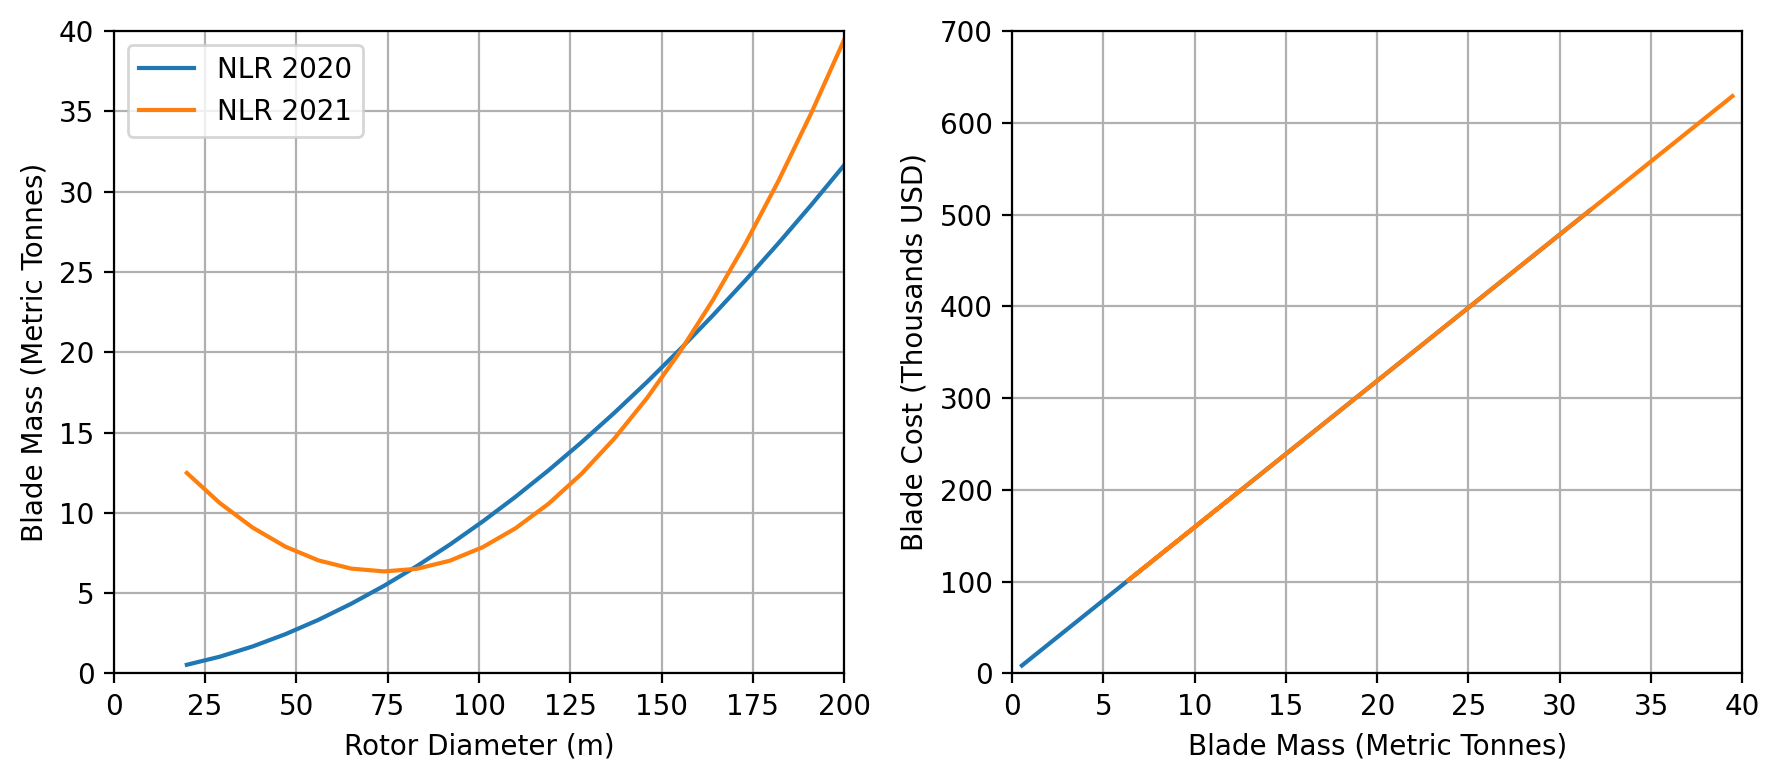

In [19]:
model_base = {"NLR 2020": {}, "NLR 2021": {}}
parameterization = {"rotor_diameter": ["range", 20, 200, 21]}


plot.plot_mass_cost_comparison(
    base_kwargs=model_base,
    parameterization=parameterization,
    component="blade",
    parameter_label="Rotor Diameter (m)",
    cost_basis="thousands",
    # reference_turbines=reference_turbs,
    mass_xlim=(0, 200),
    mass_ylim=(0, 40),
    cost_xlim=(0, 40),
    cost_ylim=(0, 700),
)